<a href="https://colab.research.google.com/github/Reva694/rawuh-model/blob/main/MLP_DIABETES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# MLP untuk Klasifikasi Penyakit Diabetes
# Google Colab - dengan Upload Dataset Sendiri
# =====================================================

# 1. Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from google.colab import files
import joblib
import io

np.random.seed(42)

In [ ]:
# =====================================================
# 2. UPLOAD DATASET
# =====================================================
print("=" * 60)
print("UPLOAD DATASET ANDA")
print("=" * 60)
print("\nSilakan upload file CSV dataset diabetes Anda...")
print("Klik tombol 'Upload' atau drag & drop file CSV")

# Upload file
uploaded = files.upload()

# Baca file yang diupload
for filename in uploaded.keys():
    print(f"\n✓ File '{filename}' berhasil diupload!")

    # Cek apakah file CSV
    if filename.endswith('.csv'):
        # Coba baca CSV
        try:
            df = pd.read_csv(io.BytesIO(uploaded[filename]))
            print(f"\nDataset berhasil dimuat!")
            print(f"Shape dataset: {df.shape}")
            print(f"\nPreview 5 baris pertama:")
            display(df.head())
            print(f"\nKolom dalam dataset: {df.columns.tolist()}")
            print(f"\nInfo data:")
            display(df.info())
            print(f"\nStatistik deskriptif:")
            display(df.describe())

            # Cek kolom target
            print("\n" + "=" * 60)
            print("SETING KOLOM TARGET")
            print("=" * 60)

            # Tampilkan kolom yang tersedia
            print("\nKolom yang tersedia dalam dataset:")
            for i, col in enumerate(df.columns, 1):
                print(f"  {i}. {col}")

            # Minta user pilih kolom target
            target_col = input("\nMasukkan nama kolom TARGET (misal: 'Outcome', 'class', dll): ").strip()

            # Validasi kolom target
            if target_col not in df.columns:
                print(f"❌ Kolom '{target_col}' tidak ditemukan!")
                print("Menggunakan kolom terakhir sebagai target...")
                target_col = df.columns[-1]
                print(f"Menggunakan kolom: {target_col}")

            # Pisahkan fitur dan target
            X = df.drop(target_col, axis=1)
            y = df[target_col]

            # Pilih fitur numerik saja (eliminasi kolom non-numerik)
            X = X.select_dtypes(include=[np.number])

            print(f"\n✓ Fitur (X): {X.shape[1]} kolom")
            print(f"✓ Target (y): {y.name}")
            print(f"✓ Distribusi target:\n{y.value_counts()}")

            # Konversi target ke binary jika perlu (0 dan 1)
            if y.nunique() == 2:
                # Pastikan target adalah 0 dan 1
                unique_vals = y.unique()
                if 0 in unique_vals and 1 in unique_vals:
                    print("✓ Target sudah dalam format binary (0, 1)")
                else:
                    # Map ke 0 dan 1
                    y = y.map({unique_vals[0]: 0, unique_vals[1]: 1})
                    print("✓ Target dikonversi ke format binary (0, 1)")
            else:
                print(f"⚠️ Target memiliki {y.nunique()} kelas unik (bukan binary)")

            break  # Keluar dari loop setelah berhasil load file

        except Exception as e:
            print(f"❌ Error membaca CSV: {e}")
            print("Coba upload file CSV yang valid")
            exit()
    else:
        print(f"❌ File '{filename}' bukan format CSV!")


UPLOAD DATASET ANDA

Silakan upload file CSV dataset diabetes Anda...
Klik tombol 'Upload' atau drag & drop file CSV


Saving diabetes.csv to diabetes (1).csv

✓ File 'diabetes (1).csv' berhasil diupload!

Dataset berhasil dimuat!
Shape dataset: (2000, 9)

Preview 5 baris pertama:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0



Kolom dalam dataset: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Info data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


None


Statistik deskriptif:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000



SETING KOLOM TARGET

Kolom yang tersedia dalam dataset:
  1. Pregnancies
  2. Glucose
  3. BloodPressure
  4. SkinThickness
  5. Insulin
  6. BMI
  7. DiabetesPedigreeFunction
  8. Age
  9. Outcome

Masukkan nama kolom TARGET (misal: 'Outcome', 'class', dll): Outcome

✓ Fitur (X): 8 kolom
✓ Target (y): Outcome
✓ Distribusi target:
Outcome
0    1316
1     684
Name: count, dtype: int64
✓ Target sudah dalam format binary (0, 1)



VISUALISASI DATA


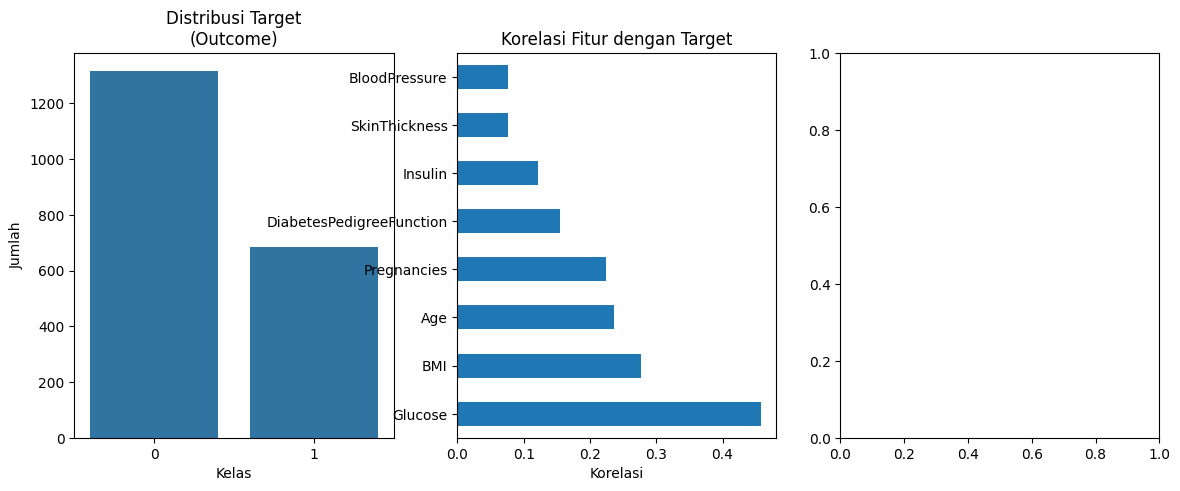

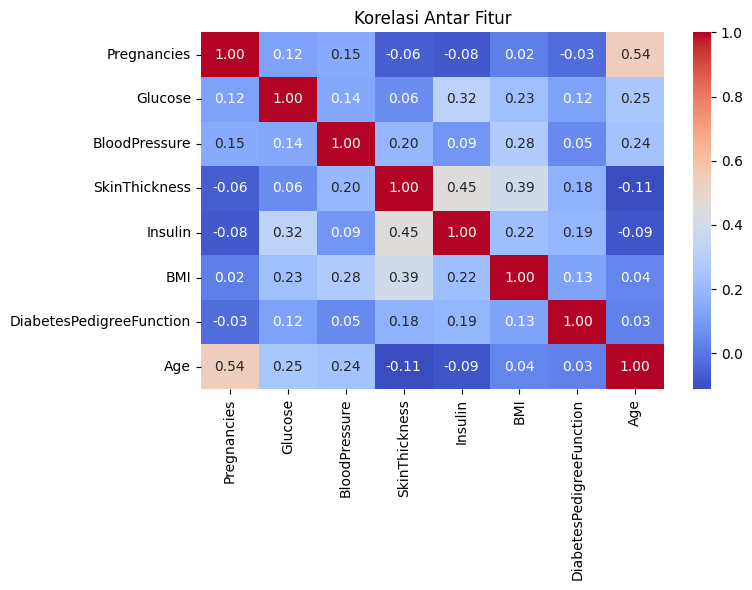


Visualisasi distribusi fitur...


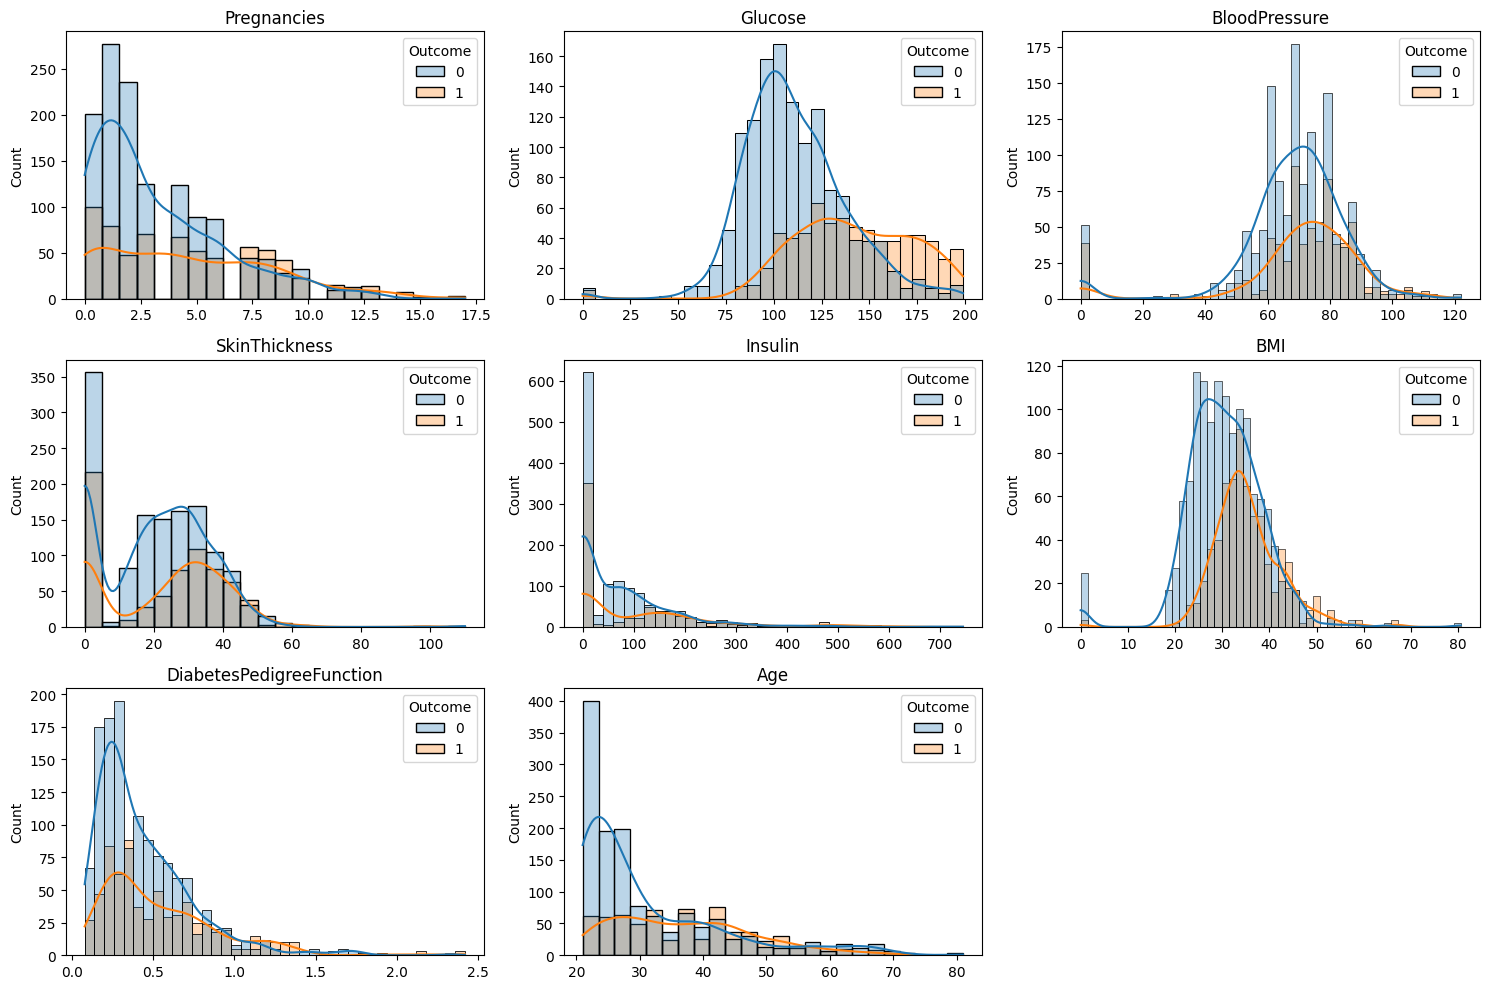

In [ ]:
# =====================================================
# 3. VISUALISASI DATA
# =====================================================
print("\n" + "=" * 60)
print("VISUALISASI DATA")
print("=" * 60)

plt.figure(figsize=(14, 5))

# Plot 1: Distribusi Target
plt.subplot(1, 3, 1)
sns.countplot(x=y)
plt.title(f'Distribusi Target\n({y.name})')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')

# Plot 2: Korelasi Fitur dengan Target
plt.subplot(1, 3, 2)
correlation = X.corrwith(y).sort_values(ascending=False)
correlation.plot(kind='barh')
plt.title('Korelasi Fitur dengan Target')
plt.xlabel('Korelasi')

# Plot 3: Heatmap Korelasi
plt.subplot(1, 3, 3)
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Fitur')

plt.tight_layout()
plt.show()

# Visualisasi distribusi setiap fitur
print("\nVisualisasi distribusi fitur...")
plt.figure(figsize=(15, 10))
for i, col in enumerate(X.columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=df, x=col, hue=y, kde=True, alpha=0.3)
    plt.title(f'{col}')
    plt.xlabel('')
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# 4. PREPROCESSING DATA
# =====================================================
print("\n" + "=" * 60)
print("PREPROCESSING DATA")
print("=" * 60)

# Cek missing values
print("Missing values dalam dataset:")
print(df.isnull().sum())

# Handle missing values (jika ada)
if X.isnull().sum().sum() > 0:
    print("\n⚠️ Terdapat missing values, mengisi dengan mean...")
    X = X.fillna(X.mean())

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData training: {X_train.shape[0]} sampel")
print(f"Data testing: {X_test.shape[0]} sampel")
print(f"Jumlah fitur: {X_train.shape[1]}")

# Standarisasi fitur (WAJIB untuk Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Standarisasi selesai (mean=0, std=1)")



PREPROCESSING DATA
Missing values dalam dataset:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data training: 1600 sampel
Data testing: 400 sampel
Jumlah fitur: 8

✓ Standarisasi selesai (mean=0, std=1)


In [ ]:
# =====================================================
# 5. BUKAT MODEL MLP CLASSIFIER
# =====================================================
print("\n" + "=" * 60)
print("MELATIH MODEL MLP")
print("=" * 60)

# Inisialisasi MLP Classifier
# Otomatis menyesuaikan jumlah neuron hidden layer dengan jumlah fitur
n_features = X_train.shape[1]
hidden_layers = (n_features * 2, n_features)  # 2x dan 1x jumlah fitur

print(f"Arsitektur MLP:")
print(f"  - Input layer: {n_features} neuron (jumlah fitur)")
print(f"  - Hidden layers: {hidden_layers} neuron")
print(f"  - Output layer: 1 neuron (binary classification)")

mlp = MLPClassifier(
    hidden_layer_sizes=hidden_layers,
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate='adaptive',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)

print("\n🚀 Melatih model...")
mlp.fit(X_train_scaled, y_train)
print("✅ Training selesai!")


MELATIH MODEL MLP
Arsitektur MLP:
  - Input layer: 8 neuron (jumlah fitur)
  - Hidden layers: (16, 8) neuron
  - Output layer: 1 neuron (binary classification)

🚀 Melatih model...
Iteration 1, loss = 0.71188374
Validation score: 0.612500
Iteration 2, loss = 0.68878032
Validation score: 0.625000
Iteration 3, loss = 0.66924842
Validation score: 0.643750
Iteration 4, loss = 0.65172731
Validation score: 0.643750
Iteration 5, loss = 0.63653985
Validation score: 0.650000
Iteration 6, loss = 0.62259711
Validation score: 0.650000
Iteration 7, loss = 0.60954945
Validation score: 0.650000
Iteration 8, loss = 0.59788423
Validation score: 0.650000
Iteration 9, loss = 0.58753747
Validation score: 0.656250
Iteration 10, loss = 0.57764129
Validation score: 0.668750
Iteration 11, loss = 0.56857515
Validation score: 0.668750
Iteration 12, loss = 0.55984052
Validation score: 0.681250
Iteration 13, loss = 0.55158944
Validation score: 0.687500
Iteration 14, loss = 0.54357586
Validation score: 0.693750
It


EVALUASI MODEL

METRIK               TRAIN           TEST           
--------------------------------------------------
Accuracy             0.7638 (76.38%)  0.7850 (78.50%)
Precision            -               0.7576 (75.76%)
Recall               -               0.5474 (54.74%)
F1-Score             -               0.6356 (63.56%)

📊 Akurasi Testing: 78.50%
✅ Model BAGUS

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Kelas 0       0.79      0.91      0.85       263
     Kelas 1       0.76      0.55      0.64       137

    accuracy                           0.79       400
   macro avg       0.78      0.73      0.74       400
weighted avg       0.78      0.79      0.77       400



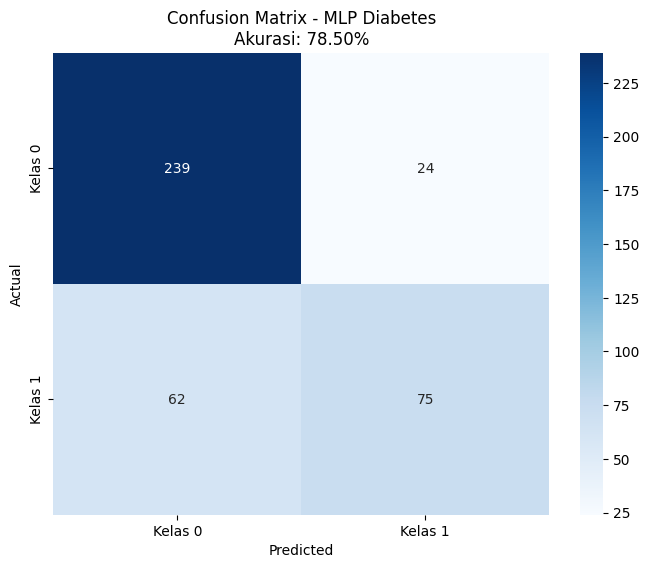

In [ ]:
# =====================================================
# 6. EVALUASI MODEL
# =====================================================
print("\n" + "=" * 60)
print("EVALUASI MODEL")
print("=" * 60)

# Prediksi
y_pred = mlp.predict(X_test_scaled)
y_pred_train = mlp.predict(X_train_scaled)

# Hitung metrik
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred)
precision_test = precision_score(y_test, y_pred)
recall_test = recall_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred)

print(f"\n{'METRIK':<20} {'TRAIN':<15} {'TEST':<15}")
print("-" * 50)
print(f"{'Accuracy':<20} {accuracy_train:.4f} ({accuracy_train:.2%})  {accuracy_test:.4f} ({accuracy_test:.2%})")
print(f"{'Precision':<20} {'-':<15} {precision_test:.4f} ({precision_test:.2%})")
print(f"{'Recall':<20} {'-':<15} {recall_test:.4f} ({recall_test:.2%})")
print(f"{'F1-Score':<20} {'-':<15} {f1_test:.4f} ({f1_test:.2%})")

print(f"\n📊 Akurasi Testing: {accuracy_test:.2%}")
if accuracy_test > 0.85:
    print("✅ Model SANGAT BAIK!")
elif accuracy_test > 0.75:
    print("✅ Model BAGUS")
elif accuracy_test > 0.65:
    print("⚠️ Model CUKUP (pertimbangkan tuning hyperparameter)")
else:
    print("⚠️ Model PERLU PENINGKATAN (coba tuning atau data lebih banyak)")

# Classification report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred,
                           target_names=['Kelas 0', 'Kelas 1']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Kelas 0', 'Kelas 1'],
            yticklabels=['Kelas 0', 'Kelas 1'])
plt.title(f'Confusion Matrix - MLP Diabetes\nAkurasi: {accuracy_test:.2%}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



TRAINING PROGRESS


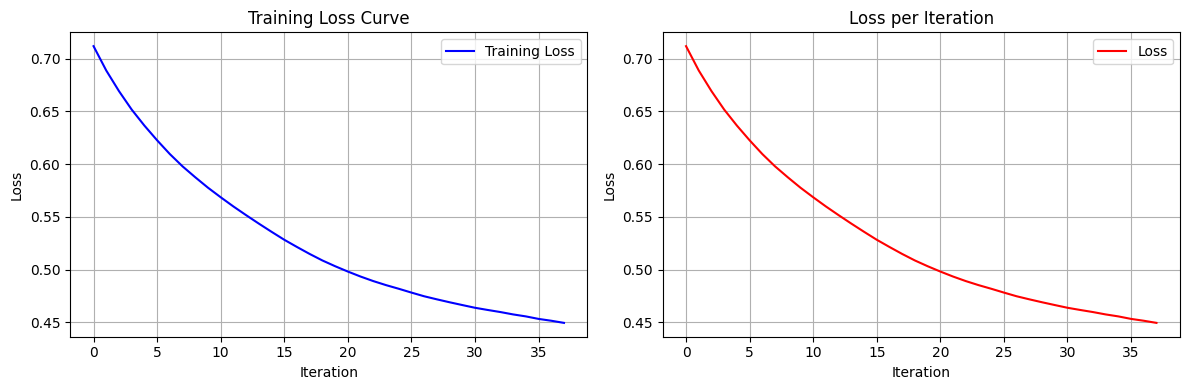

In [ ]:
# =====================================================
# 7. VISUALISASI TRAINING PROGRESS
# =====================================================
print("\n" + "=" * 60)
print("TRAINING PROGRESS")
print("=" * 60)

plt.figure(figsize=(12, 4))

# Plot loss curve
plt.subplot(1, 2, 1)
plt.plot(mlp.loss_curve_, label='Training Loss', color='blue')
plt.title('Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot accuracy training vs iteration (aproksimasi)
plt.subplot(1, 2, 2)
if hasattr(mlp, 'loss_curve_'):
    iterations = range(len(mlp.loss_curve_))
    plt.plot(iterations, mlp.loss_curve_, label='Loss', color='red')
    plt.title('Loss per Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# 8. PREDIKSI UNTUK DATA BARU
# =====================================================
print("\n" + "=" * 60)
print("PREDIKSI UNTUK DATA BARU")
print("=" * 60)

# Input data pasien baru secara interaktif
print("\nMasukkan data pasien baru untuk prediksi:")
print("(Tekan Enter untuk menggunakan data contoh)")

try:
    # Contoh input (bisa disesuaikan dengan jumlah fitur)
    patient_data = []
    for i, col in enumerate(X.columns, 1):
        try:
            val = input(f"{i}. {col} (default: {X[col].mean():.2f}): ").strip()
            if val == '':
                patient_data.append(X[col].mean())
            else:
                patient_data.append(float(val))
        except:
            patient_data.append(X[col].mean())

    patient_data = np.array([patient_data])

except:
    # Gunakan data contoh default
    print("\n⚠️ Menggunakan data contoh default")
    patient_data = np.array([[6, 148, 72, 35, 125, 33.6, 0.627, 50]])

# Standarisasi dan prediksi
patient_scaled = scaler.transform(patient_data)
prediction = mlp.predict(patient_scaled)
prediction_proba = mlp.predict_proba(patient_scaled)

print("\n" + "=" * 60)
print("HASIL PREDIKSI")
print("=" * 60)
print("\nData Pasien:")
patient_df = pd.DataFrame(patient_data, columns=X.columns)
display(patient_df)

print(f"\n🎯 Prediksi: {'⚠️ DIABETES' if prediction[0] == 1 else '✅ TIDAK DIABETES'}")
print(f"\nProbabilitas:")
print(f"  - Tidak Diabetes: {prediction_proba[0][0]:.2%}")
print(f"  - Diabetes: {prediction_proba[0][1]:.2%}")


PREDIKSI UNTUK DATA BARU

Masukkan data pasien baru untuk prediksi:
(Tekan Enter untuk menggunakan data contoh)
1. Pregnancies (default: 3.70): 
2. Glucose (default: 121.18): 
3. BloodPressure (default: 69.15): 
4. SkinThickness (default: 20.93): 
5. Insulin (default: 80.25): 
6. BMI (default: 32.19): 
7. DiabetesPedigreeFunction (default: 0.47): 
8. Age (default: 33.09): 

HASIL PREDIKSI

Data Pasien:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,3.7035,121.1825,69.1455,20.935,80.254,32.193,0.47093,33.0905



🎯 Prediksi: ✅ TIDAK DIABETES

Probabilitas:
  - Tidak Diabetes: 57.98%
  - Diabetes: 42.02%


In [ ]:
# =====================================================
# 9. SIMPAN MODEL
# =====================================================
print("\n" + "=" * 60)
print("MENYIMPAN MODEL")
print("=" * 60)

# Simpan model dan scaler
joblib.dump(mlp, 'mlp_diabetes_model.pkl')
joblib.dump(scaler, 'scaler_diabetes.pkl')
joblib.dump(X.columns, 'feature_names.pkl')

print("✅ Model MLP disimpan sebagai 'mlp_diabetes_model.pkl'")
print("✅ Scaler disimpan sebagai 'scaler_diabetes.pkl'")
print("✅ Nama fitur disimpan sebagai 'feature_names.pkl'")

# Download model ke komputer Anda
print("\n📥 Download model yang sudah dilatih?")
download = input("Ketik 'yes' untuk download: ").strip().lower()
if download == 'yes':
    files.download('mlp_diabetes_model.pkl')
    files.download('scaler_diabetes.pkl')
    print("\n✅ Model berhasil di-download!")


MENYIMPAN MODEL
✅ Model MLP disimpan sebagai 'mlp_diabetes_model.pkl'
✅ Scaler disimpan sebagai 'scaler_diabetes.pkl'
✅ Nama fitur disimpan sebagai 'feature_names.pkl'

📥 Download model yang sudah dilatih?
Ketik 'yes' untuk download: yes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Model berhasil di-download!


In [ ]:
# =====================================================
# 10. TIPS IMPROVEMENT (OPSIONAL)
# =====================================================
print("\n" + "=" * 60)
print("TIPS UNTUK MENINGKATKAN KINERJA MODEL")
print("=" * 60)
print("""
✅ Jika akurasi rendah, coba:
   1. Tambah lebih banyak data training
   2. Tuning hyperparameter (hidden_layer_sizes, alpha, learning_rate)
   3. Feature engineering (buat fitur baru dari existing fitur)
   4. Handle imbalanced data (SMOTE, class_weight)
   5. Coba algoritma lain (XGBoost, Random Forest, SVM)

📌 Untuk hyperparameter tuning, uncomment kode GridSearchCV di bawah:
""")

# =====================================================
# OPSIONAL: GRID SEARCH HYPERPARAMETER TUNING
# =====================================================
"""
from sklearn.model_selection import GridSearchCV

print("\nMelakukan Grid Search untuk hyperparameter terbaik...")
print("⚠️  Ini akan memakan waktu 5-10 menit...")

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 50, 25)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'activation': ['relu', 'tanh']
}

grid_search = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best CV Score: {grid_search.best_score_:.4f}")

# Model terbaik
best_mlp = grid_search.best_estimator_
y_pred_best = best_mlp.predict(X_test_scaled)
print(f"✅ Akurasi dengan best params: {accuracy_score(y_test, y_pred_best):.4f}")

# Simpan model terbaik
joblib.dump(best_mlp, 'mlp_diabetes_best_model.pkl')
"""

print("\n" + "=" * 60)
print("🎉 SELESAI!")
print("=" * 60)
print(f"\n📊 Akurasi Akhir: {accuracy_test:.2%}")
print("✨ Model MLP siap untuk prediksi diabetes!")


TIPS UNTUK MENINGKATKAN KINERJA MODEL

✅ Jika akurasi rendah, coba:
   1. Tambah lebih banyak data training
   2. Tuning hyperparameter (hidden_layer_sizes, alpha, learning_rate)
   3. Feature engineering (buat fitur baru dari existing fitur)
   4. Handle imbalanced data (SMOTE, class_weight)
   5. Coba algoritma lain (XGBoost, Random Forest, SVM)

📌 Untuk hyperparameter tuning, uncomment kode GridSearchCV di bawah:


🎉 SELESAI!

📊 Akurasi Akhir: 78.50%
✨ Model MLP siap untuk prediksi diabetes!
